<a href="https://colab.research.google.com/github/ilaish5/Data_Science_Course/blob/main/hw1_ilai_shalem_315702431.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1

**Name:** Ilai Shalem

**ID:** 315702431

I chose USGS earthquake catalog. The file is one month of
global earthquakes,
published on Kaggle as [USGS Earthquakes 2024](https://www.kaggle.com/datasets/rupindersinghrana/usgs-earthquakes-2024). The original data
comes from the USGS (United States Geological Survey). They collects
reports from many regional seismic networks around the world.

I picked this dataset because earthquakes are a real, and the data come from a measurement system, so it interesting: errors, missing values and
differences between the reporting networks.


# 2. Dataset choice

**2.1 Requirements** The data is tabular (CSV), has about 9,451 rows and 22 columns,
and mixes numeric columns, a time column, and
categorical columns.

**2.2 Source.**
- **Source:** USGS earthquake catalog, downloaded from [Kaggle](https://www.kaggle.com/datasets/rupindersinghrana/usgs-earthquakes-2024).
- **Purpose of collection:** operational-  earthquake alerts and emergency response.
- **Collecting organiziton:** USGS, collects reports from many regional networks.


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, zipfile

# Load the file
file_path = "/content/drive/MyDrive/Colab Notebooks/Data_science/all_month_2024.csv"
df = pd.read_csv(file_path)
print("Rows, Columns:", df.shape)
print("File Size:", os.path.getsize(file_path) / (1024 * 1024))
print()
df.info()

Rows, Columns: (9451, 22)
File Size: 1.7169523239135742

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9451 entries, 0 to 9450
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   time             9451 non-null   object 
 1   latitude         9451 non-null   float64
 2   longitude        9451 non-null   float64
 3   depth            9451 non-null   float64
 4   mag              9451 non-null   float64
 5   magType          9451 non-null   object 
 6   nst              7319 non-null   float64
 7   gap              7319 non-null   float64
 8   dmin             6175 non-null   float64
 9   rms              9451 non-null   float64
 10  net              9451 non-null   object 
 11  id               9451 non-null   object 
 12  updated          9451 non-null   object 
 13  place            9451 non-null   object 
 14  type             9451 non-null   object 
 15  horizontalError  6462 non-null   float64
 16  dep

# 3. analysis

 **3.1 File analysis**
- **File size:** ~ 1.8 MB
- **Format:** CSV
- **Creation date:** this is a snapshot of a live feed. It covers about 27 Dec 2023 - 26 Jan 2024. `time` is when the earthquake happened and `updated` is when the record was changed.
- **Purpose of the data:** operational earthquake monitoring.

In [26]:
# 3.2 Data structure

# convert  two time columns from text to datetime
df['time'] = pd.to_datetime(df['time'])
df['updated'] = pd.to_datetime(df['updated'])

df.info()
print()

print("Time range:", df['time'].min(), "to", df['time'].max())
# check if the data is already sorted by time
print("Sorted by time?", "\n", "     ascending:", df['time'].is_monotonic_increasing, "\n",
      "     descending:", df['time'].is_monotonic_decreasing)
print("id unique?", df['id'].is_unique)

pd.set_option('display.max_columns', None)
display(df.head(3))
display(df.tail(3))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9451 entries, 0 to 9450
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   time             9451 non-null   datetime64[ns, UTC]
 1   latitude         9451 non-null   float64            
 2   longitude        9451 non-null   float64            
 3   depth            9451 non-null   float64            
 4   mag              9451 non-null   float64            
 5   magType          9451 non-null   object             
 6   nst              7319 non-null   float64            
 7   gap              7319 non-null   float64            
 8   dmin             6175 non-null   float64            
 9   rms              9451 non-null   float64            
 10  net              9451 non-null   object             
 11  id               9451 non-null   object             
 12  updated          9451 non-null   datetime64[ns, UTC]
 13  place            9

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,2024-01-26 04:52:42.967000+00:00,31.604,-104.2130,4.4198,1.7,ml,18.0,69.0,0.1,0.50,tx,tx2024bubg,2024-01-26 05:08:27.774000+00:00,"51 km NW of Toyah, Texas",earthquake,0.0,1.292059,0.1,13.0,automatic,tx,tx
1,2024-01-26 04:42:50.711000+00:00,64.501,-146.9058,4.2000,1.4,ml,NaN,NaN,NaN,0.75,ak,ak024172lv8v,2024-01-26 05:01:12.516000+00:00,"2 km S of Salcha, Alaska",earthquake,NaN,0.200000,NaN,NaN,automatic,ak,ak
2,2024-01-26 04:32:51.471000+00:00,63.529,-147.5543,13.1000,1.6,ml,NaN,NaN,NaN,0.62,ak,ak024172jq57,2024-01-26 04:34:54.160000+00:00,"71 km ESE of Denali Park, Alaska",earthquake,NaN,0.300000,NaN,NaN,automatic,ak,ak


,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
9448,2023-12-27 05:34:36.680000+00:00,54.7480,-164.104667,4.200,0.67,ml,4.0,211.0,NaN,0.13,av,av91125783,2023-12-27 07:59:17.410000+00:00,"46 km WSW of False Pass, Alaska",earthquake,0.89,1.840,0.452168,4.0,reviewed,av,av
9449,2023-12-27 05:32:44.484000+00:00,43.4622,16.286000,10.000,2.70,ml,17.0,78.0,1.440,0.56,us,us6000m00f,2023-12-28 10:02:03.634000+00:00,"3 km SSE of Okrug Gornji, Croatia",earthquake,3.11,1.990,0.055000,44.0,reviewed,us,us
9450,2023-12-27 05:31:25.049000+00:00,54.7619,-164.065400,7.443,3.00,ml,23.0,83.0,0.037,0.98,us,us6000lzz7,2024-01-23 14:34:58.040000+00:00,"43 km WSW of False Pass, Alaska",earthquake,1.44,2.354,0.091000,16.0,reviewed,us,us


# 3.2 Data structure

The dataset has 9,451 rows and 22 columns. The column names split to four groups:
- **Location:** `latitude`, `longitude`, `depth`
- **Magnitude:** `mag`, `magType`
- **Measurement quality:** `nst`, `gap`, `dmin`, `rms`, `horizontalError`, `depthError`, `magError`, `magNst`
- **Source / status:** `net`, `id`, `updated`, `place`, `type`, `status`, `locationSource`, `magSource`

`time` and `updated` were loaded as text, so I converted them to datetime.

The current index is a default pandas index with no meaning. The `id` column is unique and also
has structure, it starts with the network code (like `ak`, `nc`, `us`), so it's good for a real index. The data is sorted by `time` in descending order
(newest first), which is how the USGS feed returns it.

#Discussion: research or operational data?

This data collected for operational use and not for research: they use it for real-time earthquake
alerts, so it record whatever the sensors happen to catch and processes it as fast as possible.
That creates two biases: a coverage bias (regions with more stations
report far more events) and a review bias (recent small events may
still be automatic and not checked by a person).

In [27]:
# 4.1 Missing values

# how much missing
missing_count = df.isna().sum()
precent = (missing_count / len(df) * 100).round(2)
missing = pd.DataFrame({'missing_count': missing_count, 'precent': precent})
missing = missing[missing['missing_count'] > 0].sort_values('precent')
print(missing, "\n")

#  are the columns missing in the same rows?
print("Rows missing nst:", len(df[df['nst'].isna()]))
print("Rows missing nst and gap and dmin:",
      len(df[df['nst'].isna() & df['gap'].isna() & df['dmin'].isna()]))
print("Rows missing dmin but not nst:", len(df[df['dmin'].isna() & df['nst'].notna()]))
print()

# which network is missing the location stats?
missing_rows = df[df['nst'].isna()]
print("Networks of the rows missing nst/gap/dmin:")
print(missing_rows['net'].value_counts(), "\n")



                 missing_count  precent
nst                       2132    22.56
gap                       2132    22.56
magNst                    2133    22.57
magError                  2157    22.82
horizontalError           2989    31.63
dmin                      3276    34.66 

Rows missing nst: 2132
Rows missing nst and gap and dmin: 2132
Rows missing dmin but not nst: 1144

Networks of the rows missing nst/gap/dmin:
net
ak    2132
Name: count, dtype: int64 



# 4.1 Missing values

Six columns have missing values, and they are all measurement-quality columns:
`nst`, `gap`, `magNst`, `magError` (22.56%), `horizontalError` (31.6%) and
`dmin` (34.7%).

In addition, `nst`, `gap` and `dmin` are missing in the
same 2,132 rows. On top of that,
`dmin` is missing in 1,144 extra rows.

The important part is that the rows missing `nst`/`gap`/`dmin` beolng to `net` = `ak`, every `ak` row and no other nerwork missing all three values.
Maybe the reason is that the
Alaska network sends its solutions without these particular fields.

How to handle the missing values: the standard options are to drop the row, drop a column that is mostly empty, or fill with a simple statistic (median for numerical). Here the missing is systematic,  depends on the network, so filling
`nst`/`gap`/`dmin` with a simple statistic would invent values that the `ak` network never
reported and bias the analysis. My choice is to keep the NaNs and, if a model needs them
later, add a flag column or drop these columns, since
they only describe the quality of the measurement and not the earthquake itself.

In [28]:
# 4.2 Duplicates
print("Full duplicate rows:", df.duplicated().sum())
print("Duplicate id values:", df['id'].duplicated().sum())
# same event (time, place)
print("Rows sharing time+place:",
      df.duplicated(subset=['time', 'latitude', 'longitude']).sum())

Full duplicate rows: 0
Duplicate id values: 0
Rows sharing time+place: 0


# 4.2 Duplicates

There are no duplicates: 0 full duplicate rows, 0 repeated `id` values, and 0 rows that share
the same time + location, so no rows
need to be dropped.

In [29]:
# 4.3 Suspicious values
print("Negative magnitude (mag < 0):", (df['mag'] < 0).sum(), "| min mag:", df['mag'].min())
print("Zero magnitude:", (df['mag'] == 0).sum())
print()
print("Negative depth (depth < 0):", (df['depth'] < 0).sum(), "| min depth:", df['depth'].min())
print("Depth exactly 0 km:", (df['depth'] == 0).sum())
print("Depth exactly 10 km:", (df['depth'] == 10).sum())
print("Max depth:", df['depth'].max())


Negative magnitude (mag < 0): 440 | min mag: -1.27
Zero magnitude: 31

Negative depth (depth < 0): 249 | min depth: -3.17
Depth exactly 0 km: 204
Depth exactly 10 km: 423
Max depth: 660.826


# 4.3 Suspicious values

- Negative magnitude (440 rows), plus 31 rows with magnitude exactly 0: magnitude is a logarithmic scale, so very small earthquakes can have a
  negative magnitude. The catalog includes tiny events.
- Negative / zero depth (249 rows below 0, 204 exactly 0, min -3.17 km): Depth is measured
  from sea level, so a small negative depth can mean an event slightly above the reference, but i would be careful with them.
- Depth exactly 10 km (423 rows): 10 km is a USGS default value used when the depth cannot
  be computed. So it is a default value and not a real measurement.
- Deep events up to 660 km: these are real deep earthquakes (subduction zones) and not errors.

Only depth = 10 km is an artificial default that we should remember.

In [30]:
# 4.4 Cardinality
print("Unique values per column:")
print(df.nunique().sort_values())
print()
print("Columns with a single value:", [c for c in df.columns if df[c].nunique() == 1])

Unique values per column:
status                2
type                  5
magType               9
net                  15
locationSource       15
magSource            17
nst                 148
magNst              167
mag                 565
rms                 716
gap                 941
horizontalError    1569
depthError         2023
magError           2299
depth              3563
dmin               4334
place              5057
latitude           7916
longitude          8336
time               9450
updated            9451
id                 9451
dtype: int64

Columns with a single value: []


# 4.4 Cardinality

No column has a single constant value.

The categorical columns have low cardinality and are good for grouping: `status` (2 values),
`type` (5), `magType` (9), `net` and `locationSource` (15).

On the other side, `id`, `updated`,
`time`, `latitude`, `longitude` and `place` have very high cardinality - `id` and `updated` are unique per row, and this expected.

In [31]:
# 5.1 Variable analysis - numeric
# I look at magnitude and depth.
def numeric_summary(s):
    s = s.dropna()
    mean, std = s.mean(), s.std()
    med = s.median()
    mad = (s - med).abs().median()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    # 3 outlier methods
    n_std = ((s < mean - 3*std) | (s > mean + 3*std)).sum()
    n_mad = ((s - med).abs() > 3 * mad).sum()
    n_iqr = ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()
    print("MAD:", round(mad, 3), "| IQR:", round(iqr, 3), "| Q1:", round(q1, 2), "| Q3:", round(q3, 2))
    print("outliers -> 3*std:", n_std, "| 3*MAD:", n_mad, "| 1.5*IQR:", n_iqr)

for col in ['mag', 'depth']:
    print("=====", col, "=====")
    print(df[col].describe().round(3))
    print("skewness:", round(df[col].skew(), 3))
    numeric_summary(df[col])
    print()

===== mag =====
count    9451.000
mean        1.631
std         1.238
min        -1.270
25%         0.860
50%         1.400
75%         2.000
max         7.500
Name: mag, dtype: float64
skewness: 1.135
MAD: 0.59 | IQR: 1.14 | Q1: 0.86 | Q3: 2.0
outliers -> 3*std: 51 | 3*MAD: 1259 | 1.5*IQR: 971

===== depth =====
count    9451.000
mean       21.358
std        50.810
min        -3.170
25%         2.816
50%         7.250
75%        14.300
max       660.826
Name: depth, dtype: float64
skewness: 6.73
MAD: 4.86 | IQR: 11.484 | Q1: 2.82 | Q3: 14.3
outliers -> 3*std: 141 | 3*MAD: 1865 | 1.5*IQR: 1502



# 5.1 Variable (numeric)

I look at `mag` and `depth` because they describe the earthquake itself. The other numeric
columns only describe the quality of the measurement.

- **Magnitude:** mean 1.63 is higher than the median 1.40, and the skew is 1.14. So the data
  is right-skewed: most events are small, and a few strong ones create a tail on the right
  (histogram in section 6.3).
- **Depth:** the same, but stronger: median 7.25 km, mean 21.4 km, skew 6.7. Most events are
  shallow, and deep events (up to 660 km) pull the mean up. Note: 423 depth values are exactly
  10 km - this is the USGS default from section 4.3, not a real measurement.
- **Outliers:** 3*std finds 51, 3*MAD finds 1259, 1.5*IQR finds 971 (for depth: 141 / 1865 / 1502).

Because of the skew, the median describes the data better than the mean.

In [32]:
# 5.2 Variable analysis - categorical
for col in ['net', 'type', 'magType', 'status']:
    counts = df[col].value_counts()
    pct = (counts / len(df) * 100).round(1)

    print("---", col, "---")
    print(pd.DataFrame({'count': counts, 'pct': pct}).head())
    print()

# smallest number of networks needed to cover 80% of the events
total_share = 0
n_networks_80 = 0
for share in df['net'].value_counts(normalize=True):
    total_share += share
    n_networks_80 += 1
    if total_share >= 0.80:
        break
print("Networks needed to cover 80% of the events:", n_networks_80, "out of", df['net'].nunique())
print( df['net'].value_counts().head(n_networks_80).index.tolist())

--- net ---
     count   pct
net             
ak    2132  22.6
nc    1602  17.0
ci    1063  11.2
us    1053  11.1
nn     642   6.8

--- type ---
              count   pct
type                     
earthquake     9298  98.4
quarry blast     94   1.0
explosion        33   0.3
ice quake        23   0.2
other event       3   0.0

--- magType ---
         count   pct
magType             
ml        6092  64.5
md        2421  25.6
mb         800   8.5
mww         87   0.9
mwr         29   0.3

--- status ---
           count   pct
status                
reviewed    7169  75.9
automatic   2282  24.1

Networks needed to cover 80% of the events: 7 out of 15
['ak', 'nc', 'ci', 'us', 'nn', 'tx', 'hv']


# 5.2 Variable (categorical)

- `net`: mostly US regional networks- *ak* (22.6%), *nc* (17.0%), *ci* (11.2%),
  *us* (11.1%), about 62% of the data. It takes 7 of the 15 networks to cover 80%
  of the events.
- `type`: 98.4% are earthquakes, plus small groups  (*quarry blast*, *explosion* and *ice quake*). These are not real earthquakes, so if we work on earthquakes we should filter them out.
- `magType`: mostly *ml* (64.5%) and *md* (25.6%) - the scales used for small events. Strong events use `mb`/`mww`.
- `status`: 75.9% *reviewed*, 24.1% *automatic*. The file is a snapshot from around
  26 Jan 2024, so many events were only a few days old and were not reviewed yet.

Rare categories (like `ice quake`) are small but still carry real information, so I keep
them as is.

**Discussion:** the mode represents `status` and `type` well (one value covers 76-98% of
the data), but not `net`, the most common network is only 22.6%, so one value alone does
not describe it.

Correlation matrix for pearson :
        depth   mag   nst   gap  dmin   rms  magNst
depth    1.00  0.39  0.21 -0.01  0.24  0.32    0.18
mag      0.39  1.00  0.52 -0.07  0.50  0.58    0.41
nst      0.21  0.52  1.00 -0.37  0.21  0.41    0.50
gap     -0.01 -0.07 -0.37  1.00  0.04 -0.02   -0.19
dmin     0.24  0.50  0.21  0.04  1.00  0.44    0.17
rms      0.32  0.58  0.41 -0.02  0.44  1.00    0.33
magNst   0.18  0.41  0.50 -0.19  0.17  0.33    1.00 

Correlation matrix for spearman :
        depth   mag   nst   gap  dmin   rms  magNst
depth    1.00  0.46  0.37  0.09  0.56  0.49    0.14
mag      0.46  1.00  0.58 -0.13  0.53  0.56    0.49
nst      0.37  0.58  1.00 -0.53  0.25  0.44    0.74
gap      0.09 -0.13 -0.53  1.00  0.23 -0.04   -0.48
dmin     0.56  0.53  0.25  0.23  1.00  0.66    0.09
rms      0.49  0.56  0.44 -0.04  0.66  1.00    0.21
magNst   0.14  0.49  0.74 -0.48  0.09  0.21    1.00 

Correlation matrix for kendall :
        depth   mag   nst   gap  dmin   rms  magNst
depth    1.0

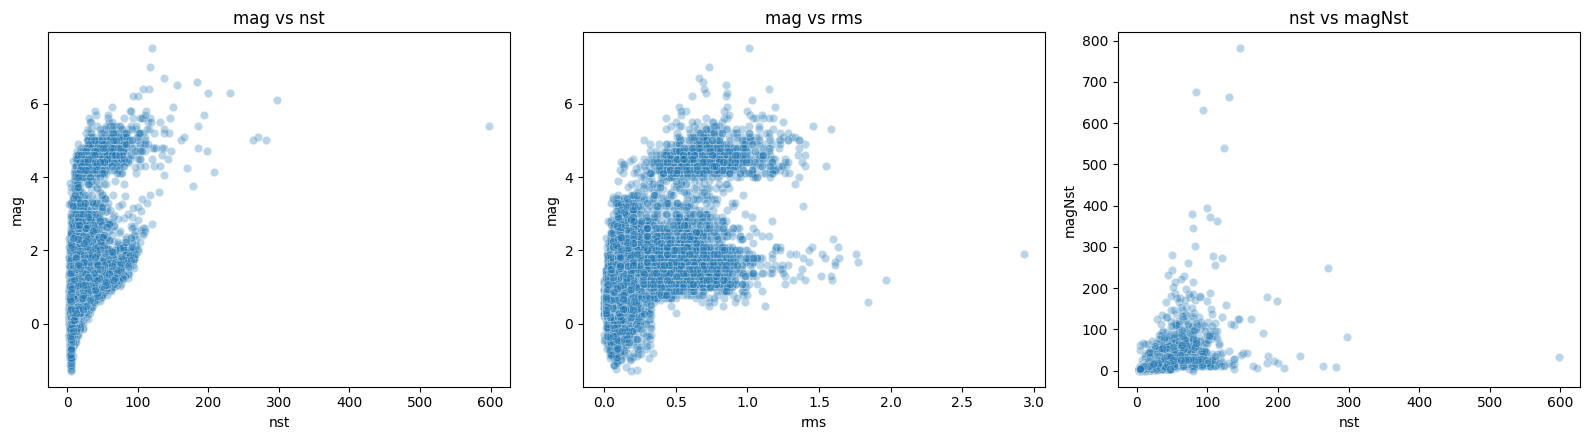

In [44]:
# 6.1 numeric correlations
num_cols = ['depth', 'mag', 'nst', 'gap', 'dmin', 'rms', 'magNst']

# correlation matrix in all 3 methods
for method in ['pearson', 'spearman', 'kendall']:
    print("Correlation matrix for", method, ":")
    print(df[num_cols].corr(method).round(2), "\n")

# zoom in on one pair (mag vs nst) to explain the difference between the methods
print("mag vs nst:")
for method in ['pearson', 'spearman', 'kendall']:
    print(" ", method, ":", round(df['mag'].corr(df['nst'], method=method), 3))

# scatter plots to see the relationships behind the correlations
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# mag vs nst
sns.scatterplot(x='nst', y='mag', data=df, alpha=0.3, ax=axes[0])
axes[0].set_title("mag vs nst")

# mag vs rms
sns.scatterplot(x='rms', y='mag', data=df, alpha=0.3, ax=axes[1])
axes[1].set_title("mag vs rms")

# nst vs magNst
sns.scatterplot(x='nst', y='magNst', data=df, alpha=0.3, ax=axes[2])
axes[2].set_title("nst vs magNst")

plt.tight_layout()
plt.show()

In [45]:
# 6.2 Categorical relationships

# crosstab: networks- reviewed vs automatic
top_nets = df['net'].value_counts().head(6).index
print("Network vs review status (top 6 networks):")
print(pd.crosstab(df['net'], df['status']).loc[top_nets])
print()

# binning: Magnitude class vs event type
mag_class = pd.cut(df['mag'], bins=[-2, 1, 3, 10], labels=['small', 'medium', 'large'])
print("Magnitude class vs event type:")
print(pd.crosstab(mag_class, df['type']))

Network vs review status (top 6 networks):
status  automatic  reviewed
net                        
ak           1012      1120
nc            904       698
ci              4      1059
us              0      1053
nn              2       640
tx             11       612

Magnitude class vs event type:
type    earthquake  explosion  ice quake  other event  quarry blast
mag                                                                
small         2968          3          0            0             9
medium        5204         30         23            2            85
large         1126          0          0            1             0


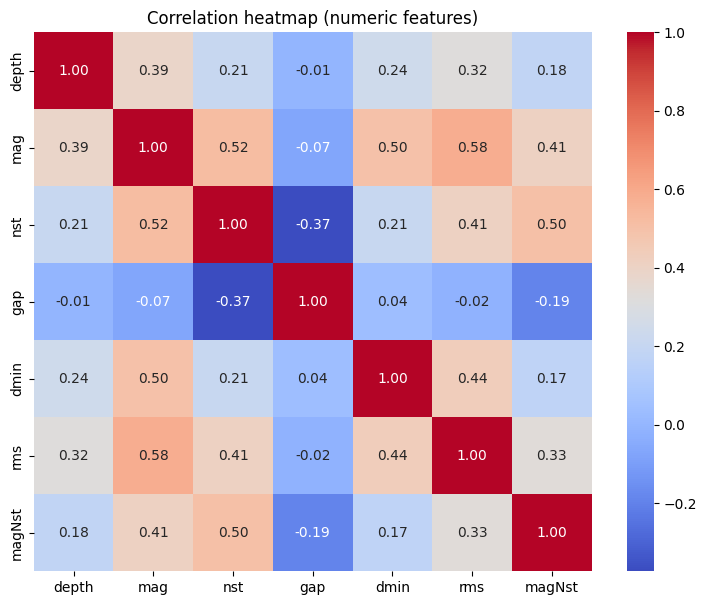

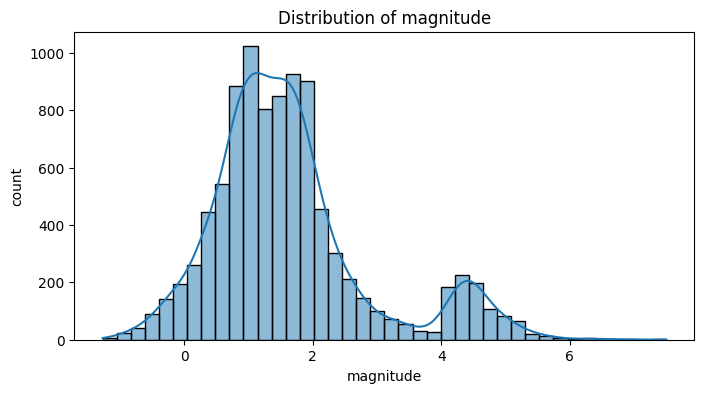

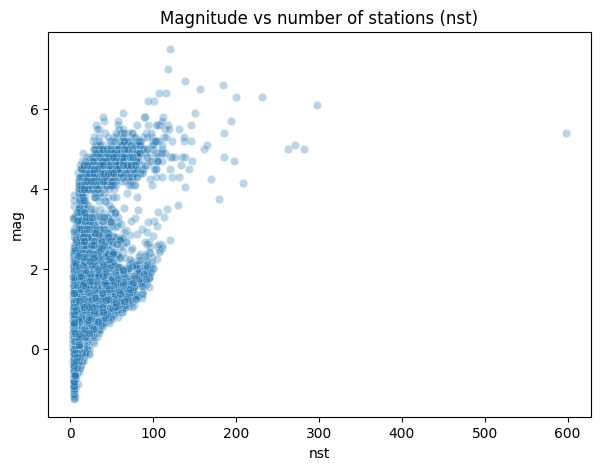

In [35]:
# 6.3 Graphs
# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df[num_cols].corr('pearson'), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation heatmap (numeric features)")
plt.show()

# Histogram - magnitude distribution
plt.figure(figsize=(8, 4))
sns.histplot(df['mag'], bins=40, kde=True)
plt.title("Distribution of magnitude")
plt.xlabel("magnitude")
plt.ylabel("count")
plt.show()

# Scatter - magnitude vs number of stations
plt.figure(figsize=(7, 5))
sns.scatterplot(x='nst', y='mag', data=df, alpha=0.3)
plt.title("Magnitude vs number of stations (nst)")
plt.show()

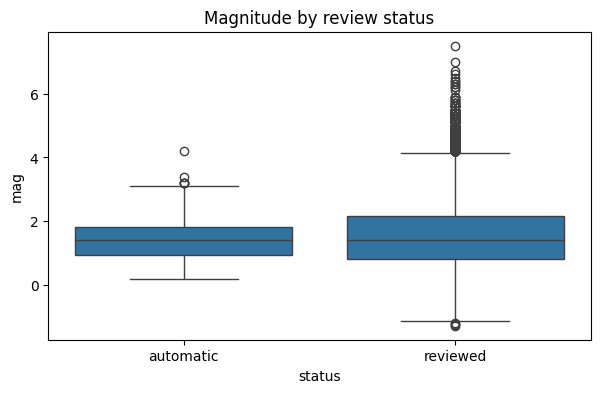

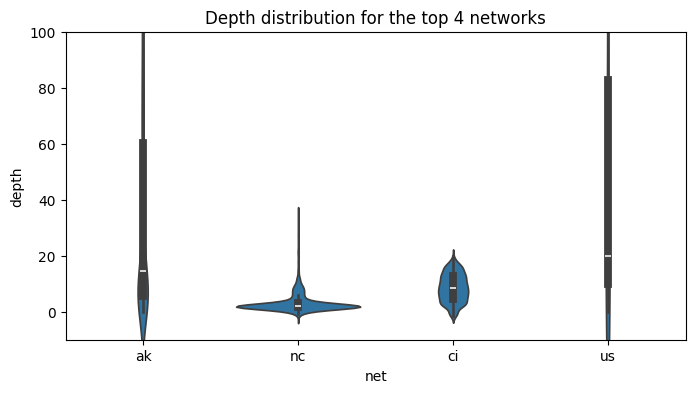

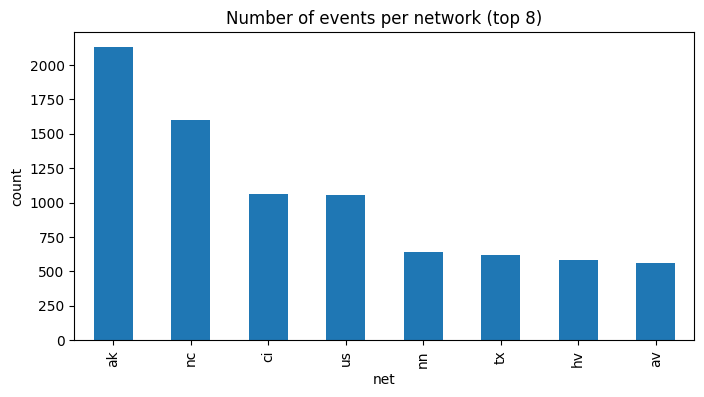

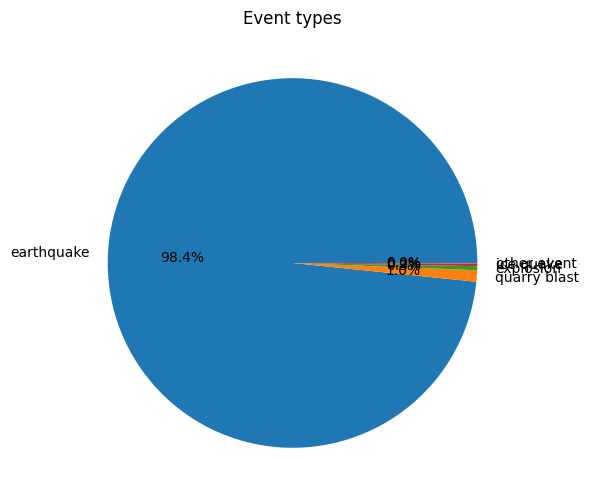

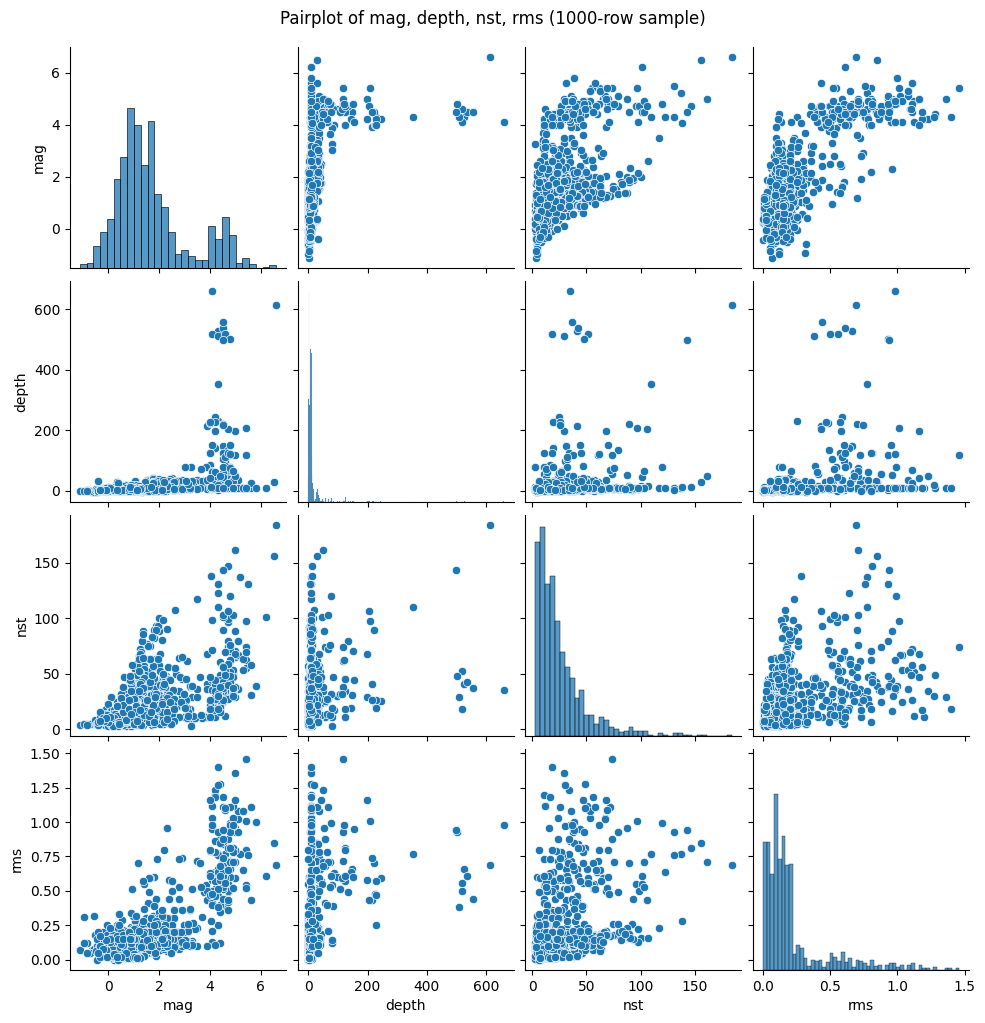

In [36]:
# More  plots

# Boxplot
plt.figure(figsize=(7, 4))
sns.boxplot(x='status', y='mag', data=df)
plt.title("Magnitude by review status")
plt.show()

# Violin
top_nets = df['net'].value_counts().head(4).index
plt.figure(figsize=(8, 4))
sns.violinplot(x='net', y='depth', data=df[df['net'].isin(top_nets)])
plt.ylim(-10, 100)
plt.title("Depth distribution for the top 4 networks")
plt.show()

# Bar chart
plt.figure(figsize=(8, 4))
df['net'].value_counts().head(8).plot(kind='bar')
plt.title("Number of events per network (top 8)")
plt.ylabel("count")
plt.show()

# Pie
plt.figure(figsize=(6, 6))
df['type'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Event types")
plt.ylabel("")
plt.show()

# Pairplot
sample = df[['mag', 'depth', 'nst', 'rms']].dropna().sample(1000, random_state=1)
pp = sns.pairplot(sample)
pp.fig.suptitle("Pairplot of mag, depth, nst, rms (1000-row sample)", y=1.02)
plt.show()

# 6. Relationships, Correlations, and Visualizations

**6.1 Numeric Correlations:**
I checked the connections between the numeric columns using the Pearson, Spearman, and Kendall methods:
* `mag` vs `rms`: This pair has the strongest linear connection (Pearson is 0.58).
* `mag` vs `nst`: There is a connection, but it is not a straight line (Spearman is 0.58 and Pearson is 0.52). This means that stronger earthquakes are detected by more stations, but not in an exact linear way.
* `nst` vs `magNst`: There is a big gap between the methods here (Spearman 0.74 vs Pearson 0.50), which means the connection is highly non-linear.

**6.2 Categorical Relationships:**
* `net` vs `status`: Different networks have different amounts of automatic vs. reviewed events. For example, `ak` and `nc` have a lot of automatic events (`ak` has 1012 automatic and 1120 reviewed), but networks like `ci` and `us` are almost 100% reviewed. This fits the finding from part 4.1 about how some networks skip fields or reviews.
* Magnitude Class vs `type`: I divided the magnitude into small, medium, and large classes. I saw that the non-earthquake events (like quarry blasts, explosions, and ice quakes) are only in the small and medium groups. The large group only has real earthquakes.

**6.3 Graphs:**
* Correlation Heatmap: Gives a good visual summary of the numeric correlations.
* Histogram: Shows that the magnitude is right-skewed, meaning most earthquakes are very small and only a few are large.
* Scatter Plots: I plotted `mag` vs `nst` and `mag` vs `rms` to see how the points look on a graph. This helps to understand the relationships behind the correlation numbers.

In [37]:
# 7. Index analysis
print("Default index has no name (RangeIndex):", df.index.name is None)
print("id unique?", df['id'].is_unique)
print("Sorted by time (descending)?", df['time'].is_monotonic_decreasing)

# set the unique id as a meaningful index
df_indexed = df.set_index('id')
print("New index name:", df_indexed.index.name, "| still unique?", df_indexed.index.is_unique)

Default index has no name (RangeIndex): True
id unique? True
Sorted by time (descending)? True
New index name: id | still unique? True


# 7. Index analysis

- **Unique?** The default index is a RangeIndex (0, 1, 2, …) with no meaning. The `id` column
  is unique, so I set it as the index to get a meaningful key.
- **Time based?** The index itself is not time based, but the rows are ordered by `time` in
  descending order (newest first), which is how the USGS feed returns the data.
- **Does the analysis change over time?** The file is only one month, so there is no long-term
  trend to worry about here; I look at the daily pattern in the bonus section.

# 8. Insights and data story

**Three main insights:**
1. Missing data comes from the reporting network: Every one of the 2,132 rows missing
   `nst`/`gap`/`dmin` is from the Alaska network, and automatic solutions skip some quality fields
   too. So the missing values mostly tell us who reported the event and how, rather than anything
   about the earthquake.
2. The catalog is dominated by dense US regional networks: Alaska plus the two California
   networks are more than half of the data, and most events are tiny (median magnitude 1.4). So
   the catalog mostly shows where the sensors are and not really where earthquakes happen. A
   country with few stations would look quiet here even if it is not.
3. "Suspicious" values are mostly real: Negative magnitudes and negative depths look wrong
   but are genuine, while depth = 10 km is an artificial default. Knowing the difference matters
   before any modeling.

A bias / risk: a strong detection / coverage bias. Because most events are from dense
US networks and the magnitudes are mostly small, a model trained on this month would learn "US
small earthquakes" and would not generalize to other regions or to large events.

**Possible failure points for an ML model:**
- Using `nst`/`gap`/`dmin` as features would leak the network (they are missing exactly for
  `ak`), so the model could just learn if the event came from Alaska instead of learning something real.
- The depth = 10 km placeholder and the negative depths would confuse a model that treats depth
  as a clean measurement.
- Judging a model by accuracy on the rare classes (quarry blast, ice quake) would be misleading,
  because they are tiny groups.

What I learned: before this homework I thought of an earthquake catalog as objective truth. Now I
see it is the output of a measurement network, with its own reporting rules and coverage bias. The
most useful step for me was checking why values are missing and not just counting them.

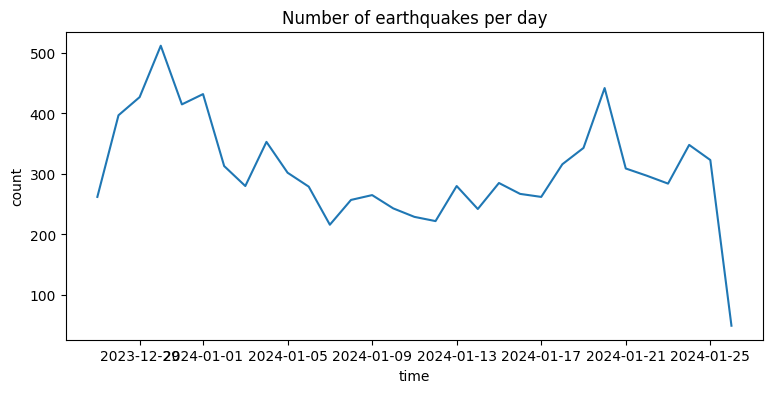

Quarry blasts by weekday:
weekday
Monday       14
Tuesday      13
Wednesday    28
Thursday     19
Friday       20
Saturday      0
Sunday        0
Name: count, dtype: int64

Chi-square vs uniform:  chi2 = 48.23  p-value = 0.0


In [38]:
# 9. time dependence and a simple engineered feature

# events per day
per_day = df['time'].dt.date.value_counts().sort_index()
plt.figure(figsize=(9, 4))
per_day.plot()
plt.title("Number of earthquakes per day")
plt.ylabel("count")
plt.show()

# feature engineering + a hypothesis test: quarry blasts should happen on work days
from scipy.stats import chisquare
df['weekday'] = df['time'].dt.day_name()
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
qb = df[df['type'] == 'quarry blast']['weekday'].value_counts().reindex(days, fill_value=0)
print("Quarry blasts by weekday:")
print(qb)

# H0: quarry blasts are spread evenly across the 7 days. Expected = same count each day.
expected = [qb.sum() / 7] * 7
chi2, pval = chisquare(qb.values, expected)
print("\nChi-square vs uniform:  chi2 =", round(chi2, 2), " p-value =", round(pval, 6))

# 9. Bonus

- **Time:** The number of events per day is fairly stable, with a few spikes that are probably
  aftershock sequences (one strong event followed by many small ones on the same day). This fits
  what I read about earthquakes, they come in clusters (mainshock + aftershocks) and not evenly in time.
- **Feature idea + hypothesis test:** I added a `weekday` feature and tested a real hypothesis:
  quarry blasts should happen on work days, not weekends, because quarries do not blast on the
  weekend. The counts are heavily concentrated on weekdays (almost none on Saturday/Sunday), and a
  chi-square test against a uniform spread gives a tiny p-value, so I reject the idea that they are
  spread evenly over the week. This is a nice sanity check that the `type` label is meaningful.
- **Idea for further research:** Join the data with station locations to measure the coverage bias
  directly, or use several months of data to study how aftershocks decay over time.